# Model Evidence: Crypto Perpetual Futures

Which predictive family supplies the strongest validation signal once checkpoint files and
evaluation samples are made comparable? This notebook reconstructs the physical prediction
artifacts in the current-lineage registry and compares their leaders on common decision keys.

**Learning objectives**

- Select models with per-decision-time IC rather than fold-average IC
- Separate physical checkpoints stored together in one prediction artifact
- Compare model families on the same timestamps and symbols
- Keep predictive, structural, and causal evidence in distinct lanes

**Book reference**: Chapters 11-15 model comparison and Chapter 20 strategy synthesis

**Prerequisites**: [`06_linear`](06_linear.ipynb), [`07_gbm`](07_gbm.ipynb),
[`08_tabular_dl`](08_tabular_dl.ipynb), [`09_dl_lstm`](09_dl_lstm.ipynb),
[`10_dl_tcn`](10_dl_tcn.ipynb), and [`11_causal_dml`](11_causal_dml.ipynb)

In [1]:
"""Physical-checkpoint model comparison on a common validation panel."""

import sqlite3
from datetime import datetime, timedelta

import numpy as np
import plotly.graph_objects as go
import polars as pl
import torch  # noqa: F401
import yaml
from ml4t.diagnostic.metrics import compute_ic_uncertainty

from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [2]:
CASE_STUDY = "crypto_perps_funding"
PRIMARY_LABEL = "fwd_ret_8h"
N_BUCKETS = 5
SEED = 42
LABEL_HORIZON_HOURS = 8

In [3]:
set_global_seeds(SEED)
CASE_DIR = get_case_study_dir(CASE_STUDY)
REGISTRY_PATH = CASE_DIR / "run_log" / "registry.db"
PREDICTION_DIR = CASE_DIR / "run_log" / "predictions"
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
HOLDOUT_START = setup["evaluation"]["holdout_start"]
PREDICTIVE_FAMILIES = ["linear", "gbm", "tabular_dl", "deep_learning"]
FAMILY_LABELS = {
    "linear": "Linear",
    "gbm": "GBM",
    "tabular_dl": "TabM",
    "deep_learning": "Sequence DL",
}

print(f"Primary label: {PRIMARY_LABEL}")
print(f"Sealed holdout starts: {HOLDOUT_START}")

Primary label: fwd_ret_8h
Sealed holdout starts: 2024-01-01


## Establish the artifact contract

The registry identifies validation artifacts, but a physical parquet may contain more than one
epoch. Selection therefore inspects the parquet itself. The query is read-only and excludes the
holdout before any model comparison.

In [4]:
def _prediction_inventory(registry_path) -> pl.DataFrame:
    """Return one row per registered validation prediction artifact."""
    query = """
        SELECT t.family, t.config_name, t.label, p.prediction_hash,
               p.checkpoint_value, p.checkpoint_kind, p.created_at
        FROM training_runs t
        JOIN prediction_sets p USING (training_hash)
        WHERE t.label = ? AND p.split = 'validation'
          AND t.family IN ('linear', 'gbm', 'tabular_dl', 'deep_learning')
        ORDER BY t.family, t.config_name, p.created_at
    """
    uri = f"file:{registry_path}?mode=ro"
    with sqlite3.connect(uri, uri=True) as connection:
        return pl.read_database(
            query,
            connection,
            execute_options={"parameters": (PRIMARY_LABEL,)},
        )

In [5]:
def _prediction_metrics(registry_path) -> pl.DataFrame:
    """Return exact registered metric rows with their physical artifact hashes."""
    query = """
        SELECT t.family, t.config_name, p.prediction_hash,
               p.checkpoint_value, p.checkpoint_kind, p.created_at,
               pm.ic_mean_daily, pm.ic_n_days
        FROM prediction_metrics pm
        JOIN prediction_sets p USING (prediction_hash)
        JOIN training_runs t USING (training_hash)
        WHERE t.label = ? AND p.split = 'validation'
          AND t.family IN ('linear', 'gbm', 'deep_learning')
          AND pm.ic_mean_daily IS NOT NULL AND pm.ic_n_days IS NOT NULL
          AND p.prediction_hash NOT IN (
              SELECT prediction_hash FROM fold_metrics WHERE ic IS NULL
          )
        ORDER BY t.family, pm.ic_mean_daily DESC, p.created_at DESC
    """
    uri = f"file:{registry_path}?mode=ro"
    with sqlite3.connect(uri, uri=True) as connection:
        return pl.read_database(
            query,
            connection,
            execute_options={"parameters": (PRIMARY_LABEL,)},
        )

In [6]:
inventory = _prediction_inventory(REGISTRY_PATH)
if inventory.is_empty():
    raise RuntimeError("No registered validation predictions")
print(
    inventory.group_by("family")
    .agg(pl.len().alias("artifacts"), pl.col("config_name").n_unique().alias("configs"))
    .sort("family")
)

shape: (4, 3)
┌───────────────┬───────────┬─────────┐
│ family        ┆ artifacts ┆ configs │
│ ---           ┆ ---       ┆ ---     │
│ str           ┆ u32       ┆ u32     │
╞═══════════════╪═══════════╪═════════╡
│ deep_learning ┆ 40        ┆ 2       │
│ gbm           ┆ 15        ┆ 15      │
│ linear        ┆ 28        ┆ 28      │
│ tabular_dl    ┆ 12        ┆ 3       │
└───────────────┴───────────┴─────────┘


Prediction files use two legacy column spellings and mixed timestamp precision. Normalizing those
representation details is safe; model scores, targets, folds, and decision keys are unchanged.

In [7]:
def _read_prediction_artifact(prediction_hash: str) -> pl.DataFrame:
    """Load one artifact with canonical columns and timestamp dtype."""
    frame = pl.read_parquet(PREDICTION_DIR / prediction_hash / "predictions.parquet")
    renames = {
        old: new
        for old, new in {"actual": "y_true", "prediction": "y_score", "fold": "fold_id"}.items()
        if old in frame.columns
    }
    if renames:
        frame = frame.rename(renames)
    timestamp = frame.schema["timestamp"]
    if isinstance(timestamp, pl.Datetime) and timestamp.time_zone is not None:
        frame = frame.with_columns(pl.col("timestamp").dt.replace_time_zone(None))
    frame = frame.with_columns(pl.col("timestamp").cast(pl.Datetime("ms")))
    holdout_start = datetime.fromisoformat(HOLDOUT_START)
    valid = pl.col("timestamp") + pl.duration(hours=LABEL_HORIZON_HOURS) < holdout_start
    boundary_rows = frame.filter(~valid).height
    if boundary_rows:
        print(f"Excluded {boundary_rows:,} holdout-touching rows from {prediction_hash}")
    return frame.filter(valid)

## Recompute decision-time IC

Spearman IC is computed within each decision timestamp and then averaged. The series is sorted
before HAC uncertainty is estimated. This is the selection statistic used throughout the case
study; fold means never rank candidates here.

In [8]:
def _daily_ic(frame: pl.DataFrame) -> pl.DataFrame:
    """Return the sorted decision-time rank-IC series."""
    return (
        frame.with_columns(
            pl.col("y_true").rank("average").over("timestamp").alias("actual_rank"),
            pl.col("y_score").rank("average").over("timestamp").alias("score_rank"),
        )
        .group_by("timestamp")
        .agg(pl.corr("actual_rank", "score_rank").alias("ic"), pl.len().alias("n_symbols"))
        .filter(pl.col("n_symbols") >= 5)
        .drop_nulls("ic")
        .sort("timestamp")
    )

In [9]:
def _ic_summary(frame: pl.DataFrame) -> dict:
    """Summarize one physical prediction slice with HAC uncertainty."""
    series = _daily_ic(frame)
    uncertainty = compute_ic_uncertainty(series.select("ic"), horizon=1, n_boot=500)
    return {
        "ic": float(uncertainty["mean_ic"]),
        "ci_lo": float(uncertainty["ci_hac_lower"]),
        "ci_hi": float(uncertainty["ci_hac_upper"]),
        "t_hac": float(uncertainty["t_hac"]),
        "p_hac": float(uncertainty["p_hac"]),
        "n_dates": series.height,
        "n_rows": frame.height,
    }

## Separate TabM's physical epochs

Each current TabM checkpoint has its own physical prediction artifact. The inventory still reads
the physical epoch when present so a legacy multi-epoch file cannot silently duplicate keys.

In [10]:
tabm_rows = []
for row in inventory.filter(pl.col("family") == "tabular_dl").iter_rows(named=True):
    artifact = _read_prediction_artifact(row["prediction_hash"])
    checkpoints = (
        sorted(artifact["epoch"].unique().to_list())
        if "epoch" in artifact.columns
        else [row["checkpoint_value"]]
    )
    for checkpoint in checkpoints:
        physical = (
            artifact.filter(pl.col("epoch") == checkpoint)
            if "epoch" in artifact.columns
            else artifact
        )
        duplicate_keys = physical.select(
            pl.struct(["timestamp", "symbol", "fold_id"]).is_duplicated().sum()
        ).item()
        summary = _ic_summary(physical)
        tabm_rows.append(
            {
                "family": "tabular_dl",
                "config_name": row["config_name"],
                "prediction_hash": row["prediction_hash"],
                "epoch": int(checkpoint) if checkpoint is not None else None,
                "n_null": physical["y_score"].null_count(),
                "duplicate_keys": int(duplicate_keys),
                **summary,
            }
        )

Complete decision-date coverage is an eligibility condition, not a tiebreaker. This prevents a
short, favorable vintage from winning against artifacts evaluated over the full validation span.

In [11]:
tabm_candidates = pl.DataFrame(tabm_rows)
max_tabm_dates = tabm_candidates["n_dates"].max()
eligible_tabm = tabm_candidates.filter(
    (pl.col("n_dates") == max_tabm_dates)
    & (pl.col("n_null") == 0)
    & (pl.col("duplicate_keys") == 0)
)
tabm_leader = eligible_tabm.sort("ic", descending=True).row(0, named=True)
print(
    f"Current TabM physical leader: {tabm_leader['config_name']} epoch {tabm_leader['epoch']} "
    f"| IC={tabm_leader['ic']:+.6f} | dates={tabm_leader['n_dates']:,}"
)

Current TabM physical leader: tabm_s epoch 50 | IC=+0.015096 | dates=2,183


The remaining three families store one physical checkpoint per registered artifact. Their leaders
are selected from exact registry rows using `ic_mean_daily`, the decision-time statistic. The
selected row retains its `prediction_hash`; repeated runs of one config are never averaged or
resolved later by timestamp.

In [12]:
def _select_registry_leaders(metrics: pl.DataFrame) -> pl.DataFrame:
    """Select complete exact rows without aggregating repeated config runs."""
    if set(metrics["family"].unique()) != {"linear", "gbm", "deep_learning"}:
        raise RuntimeError("Exact daily-IC registry rows are missing for a predictive family")
    complete = metrics.filter(pl.col("ic_n_days") == pl.col("ic_n_days").max().over("family"))
    return complete.sort("ic_mean_daily", descending=True).group_by("family").first().sort("family")

In [13]:
metrics = _prediction_metrics(REGISTRY_PATH)
registry_leaders = _select_registry_leaders(metrics)
sequence_leader = registry_leaders.filter(pl.col("family") == "deep_learning").row(0, named=True)
FAMILY_LABELS["deep_learning"] = (
    "LSTM" if sequence_leader["config_name"].startswith("lstm") else "TCN"
)
print(
    registry_leaders.select(
        "family",
        "config_name",
        "prediction_hash",
        "checkpoint_value",
        "ic_mean_daily",
        "ic_n_days",
    )
)

shape: (3, 6)
┌───────────────┬───────────────┬─────────────────┬──────────────────┬───────────────┬───────────┐
│ family        ┆ config_name   ┆ prediction_hash ┆ checkpoint_value ┆ ic_mean_daily ┆ ic_n_days │
│ ---           ┆ ---           ┆ ---             ┆ ---              ┆ ---           ┆ ---       │
│ str           ┆ str           ┆ str             ┆ i64              ┆ f64           ┆ f64       │
╞═══════════════╪═══════════════╪═════════════════╪══════════════════╪═══════════════╪═══════════╡
│ deep_learning ┆ lstm_h64      ┆ c09e48d14108    ┆ 15               ┆ 0.017955      ┆ 2183.0    │
│ gbm           ┆ leaves_63_mse ┆ 2858300ac68c    ┆ null             ┆ 0.028847      ┆ 2183.0    │
│ linear        ┆ ridge_a1.0    ┆ d2d0443f6bd1    ┆ null             ┆ 0.007021      ┆ 2183.0    │
└───────────────┴───────────────┴─────────────────┴──────────────────┴───────────────┴───────────┘


## Assemble one physical prediction frame per leader

Metadata selects the parquet; an internal epoch filter selects the physical checkpoint. Every
resulting frame must have unique decision keys and must end before the sealed holdout.

In [14]:
def _load_leader(
    family: str,
    config_name: str,
    prediction_hash: str,
    checkpoint: int | None,
) -> pl.DataFrame:
    """Load the exact selected artifact and its physical checkpoint."""
    row = inventory.filter(
        (pl.col("family") == family)
        & (pl.col("config_name") == config_name)
        & (pl.col("prediction_hash") == prediction_hash)
    )
    if row.height != 1:
        raise ValueError(f"Expected exact artifact {prediction_hash} for {family}/{config_name}")
    frame = _read_prediction_artifact(prediction_hash)
    if "epoch" in frame.columns and checkpoint is not None:
        frame = frame.filter(pl.col("epoch") == checkpoint)
    required = ["timestamp", "symbol", "fold_id", "y_true", "y_score"]
    frame = frame.select(required).drop_nulls(required)
    if frame.select(pl.col("y_true", "y_score").is_finite().all()).row(0) != (True, True):
        raise ValueError(f"Non-finite score or target for {family}/{config_name}")
    if frame.select(pl.struct(["timestamp", "symbol", "fold_id"]).is_duplicated().any()).item():
        raise ValueError(f"Duplicate physical keys for {family}/{config_name}")
    if frame["timestamp"].max() + timedelta(hours=LABEL_HORIZON_HOURS) >= datetime.fromisoformat(
        HOLDOUT_START
    ):
        raise ValueError(f"Holdout observations entered {family}/{config_name}")
    return frame.with_columns(
        pl.lit(family).alias("family"),
        pl.lit(config_name).alias("config_name"),
        pl.lit(checkpoint).cast(pl.Int64).alias("checkpoint"),
    )

In [15]:
leader_frames = []
for row in registry_leaders.iter_rows(named=True):
    checkpoint = row["checkpoint_value"]
    leader_frames.append(
        _load_leader(row["family"], row["config_name"], row["prediction_hash"], checkpoint)
    )
leader_frames.append(
    _load_leader(
        "tabular_dl",
        tabm_leader["config_name"],
        tabm_leader["prediction_hash"],
        tabm_leader["epoch"],
    )
)

for frame in sorted(leader_frames, key=lambda item: item["family"][0]):
    print(
        f"{frame['family'][0]:14s} {frame['config_name'][0]:22s} "
        f"rows={frame.height:,} dates={frame['timestamp'].n_unique():,}"
    )

deep_learning  lstm_h64               rows=35,228 dates=2,183
gbm            leaves_63_mse          rows=35,408 dates=2,183
linear         ridge_a1.0             rows=35,408 dates=2,183
tabular_dl     tabm_s                 rows=35,408 dates=2,183


## Align the comparison panel

Fold identifiers are training metadata, not economic keys. The fair comparison intersects
`timestamp` and `symbol` across all four families. Targets use mixed physical precision, so
identity is checked after Float32 normalization, the narrowest stored target representation.
Missing families, duplicate economic keys, an empty intersection, or contradictory normalized
targets stop execution.

In [16]:
def _assert_target_identity(aligned: list[pl.DataFrame]) -> None:
    """Require equal realized targets after documented Float32 normalization."""
    reference = aligned[0].select(
        "timestamp", "symbol", pl.col("y_true").cast(pl.Float32).alias("reference_target")
    )
    for frame in aligned[1:]:
        family = frame["family"][0]
        candidate = frame.select(
            "timestamp", "symbol", pl.col("y_true").cast(pl.Float32).alias("candidate_target")
        )
        mismatches = (
            candidate.join(reference, on=["timestamp", "symbol"], how="inner")
            .filter(pl.col("candidate_target") != pl.col("reference_target"))
            .height
        )
        if mismatches:
            raise ValueError(
                f"Normalized realized targets disagree for {family}: {mismatches} rows"
            )

In [17]:
def _assemble_common_panel(
    frames: list[pl.DataFrame],
) -> tuple[list[pl.DataFrame], pl.DataFrame]:
    """Align exactly the declared families and verify normalized target identity."""
    by_family = {frame["family"][0]: frame for frame in frames}
    if len(frames) != len(PREDICTIVE_FAMILIES) or set(by_family) != set(PREDICTIVE_FAMILIES):
        raise ValueError(f"Expected exactly these families: {', '.join(PREDICTIVE_FAMILIES)}")
    for family, frame in by_family.items():
        if frame.select(pl.struct(["timestamp", "symbol"]).is_duplicated().any()).item():
            raise ValueError(f"Duplicate economic keys for {family}")

    common_keys = by_family[PREDICTIVE_FAMILIES[0]].select("timestamp", "symbol")
    for family in PREDICTIVE_FAMILIES[1:]:
        common_keys = common_keys.join(
            by_family[family].select("timestamp", "symbol"),
            on=["timestamp", "symbol"],
            how="inner",
        )
    common_keys = common_keys.sort(["timestamp", "symbol"])
    if common_keys.is_empty():
        raise ValueError("The four predictive families have no common economic panel")

    aligned = [
        by_family[family].join(common_keys, on=["timestamp", "symbol"], how="inner")
        for family in PREDICTIVE_FAMILIES
    ]
    _assert_target_identity(aligned)
    return aligned, common_keys

In [18]:
aligned_frames, common_keys = _assemble_common_panel(leader_frames)
print(
    f"Common panel: {common_keys.height:,} rows, {common_keys['timestamp'].n_unique():,} "
    f"timestamps, {common_keys['timestamp'].min()} to {common_keys['timestamp'].max()}"
)

Common panel: 35,228 rows, 2,183 timestamps, 2022-01-03 00:00:00 to 2023-12-31 08:00:00


## Compare current family leaders on one validation window

The forest plot recomputes every point and interval from the shared physical panel. This avoids
comparing family metrics evaluated on different physical rows.

In [19]:
leader_stats = []
for frame in aligned_frames:
    leader_stats.append(
        {
            "family": frame["family"][0],
            "config_name": frame["config_name"][0],
            **_ic_summary(frame),
        }
    )
comparison = pl.DataFrame(leader_stats).sort("ic", descending=True)
print(comparison.select("family", "config_name", "ic", "ci_lo", "ci_hi", "p_hac", "n_dates"))

shape: (4, 7)
┌───────────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬─────────┐
│ family        ┆ config_name   ┆ ic       ┆ ci_lo     ┆ ci_hi    ┆ p_hac    ┆ n_dates │
│ ---           ┆ ---           ┆ ---      ┆ ---       ┆ ---      ┆ ---      ┆ ---     │
│ str           ┆ str           ┆ f64      ┆ f64       ┆ f64      ┆ f64      ┆ i64     │
╞═══════════════╪═══════════════╪══════════╪═══════════╪══════════╪══════════╪═════════╡
│ gbm           ┆ leaves_63_mse ┆ 0.028467 ┆ 0.015865  ┆ 0.041069 ┆ 0.00001  ┆ 2183    │
│ deep_learning ┆ lstm_h64      ┆ 0.017955 ┆ 0.005656  ┆ 0.030255 ┆ 0.00424  ┆ 2183    │
│ tabular_dl    ┆ tabm_s        ┆ 0.015686 ┆ 0.00348   ┆ 0.027892 ┆ 0.011804 ┆ 2183    │
│ linear        ┆ ridge_a1.0    ┆ 0.006325 ┆ -0.005843 ┆ 0.018493 ┆ 0.30816  ┆ 2183    │
└───────────────┴───────────────┴──────────┴───────────┴──────────┴──────────┴─────────┘


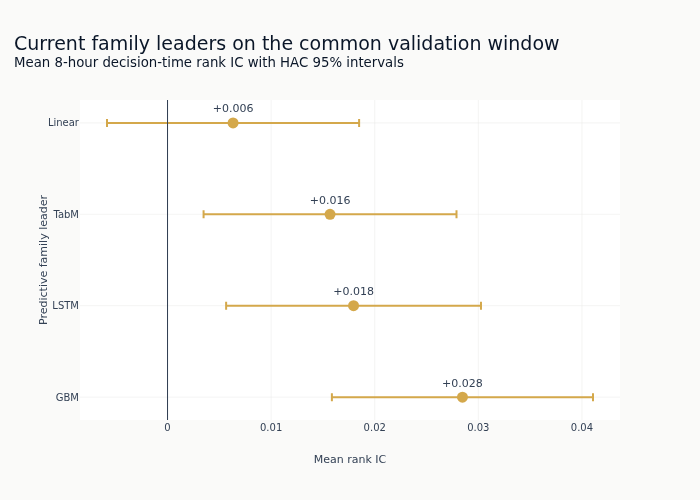

In [20]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=comparison["ic"],
        y=[FAMILY_LABELS[value] for value in comparison["family"]],
        mode="markers+text",
        text=[f"{value:+.3f}" for value in comparison["ic"]],
        textposition="top center",
        marker={"size": 11, "color": COLORS["amber"]},
        error_x={
            "type": "data",
            "symmetric": False,
            "array": (comparison["ci_hi"] - comparison["ic"]).to_list(),
            "arrayminus": (comparison["ic"] - comparison["ci_lo"]).to_list(),
        },
    )
)
fig.add_vline(x=0, line_color=COLORS["neutral"], line_width=1)
fig.update_layout(
    title={
        "text": "Current family leaders on the common validation window"
        "<br><sup>Mean 8-hour decision-time rank IC with HAC 95% intervals</sup>",
        "x": 0.02,
        "xanchor": "left",
    },
    xaxis_title="Mean rank IC",
    yaxis_title="Predictive family leader",
    showlegend=False,
)
fig.show()

## Pair the sequence leader against every challenger

A family can clear zero without beating another family. The decision statistic therefore pairs
the two daily IC series on the common timestamps and estimates uncertainty for their difference.
This uses the common decision-time series rather than treating the small set of folds as
observations.

In [21]:
daily_by_family = {
    frame["family"][0]: _daily_ic(frame).select("timestamp", "ic") for frame in aligned_frames
}
sequence_daily = daily_by_family["deep_learning"].rename({"ic": "sequence_ic"})
delta_rows = []
for family in [value for value in daily_by_family if value != "deep_learning"]:
    paired = sequence_daily.join(
        daily_by_family[family].rename({"ic": "challenger_ic"}), on="timestamp", how="inner"
    ).with_columns((pl.col("sequence_ic") - pl.col("challenger_ic")).alias("ic"))
    uncertainty = compute_ic_uncertainty(paired.select("ic"), horizon=1, n_boot=500)
    delta_rows.append(
        {
            "challenger": family,
            "delta": uncertainty["mean_ic"],
            "ci_lo": uncertainty["ci_hac_lower"],
            "ci_hi": uncertainty["ci_hac_upper"],
            "p_hac": uncertainty["p_hac"],
            "n_dates": uncertainty["n_days"],
        }
    )
paired_deltas = pl.DataFrame(delta_rows).sort("delta")
print(paired_deltas)

shape: (3, 6)
┌────────────┬───────────┬───────────┬──────────┬──────────┬─────────┐
│ challenger ┆ delta     ┆ ci_lo     ┆ ci_hi    ┆ p_hac    ┆ n_dates │
│ ---        ┆ ---       ┆ ---       ┆ ---      ┆ ---      ┆ ---     │
│ str        ┆ f64       ┆ f64       ┆ f64      ┆ f64      ┆ i64     │
╞════════════╪═══════════╪═══════════╪══════════╪══════════╪═════════╡
│ gbm        ┆ -0.010511 ┆ -0.027494 ┆ 0.006472 ┆ 0.224973 ┆ 2183    │
│ tabular_dl ┆ 0.002269  ┆ -0.013632 ┆ 0.018171 ┆ 0.779593 ┆ 2183    │
│ linear     ┆ 0.011631  ┆ -0.004801 ┆ 0.028062 ┆ 0.165255 ┆ 2183    │
└────────────┴───────────┴───────────┴──────────┴──────────┴─────────┘


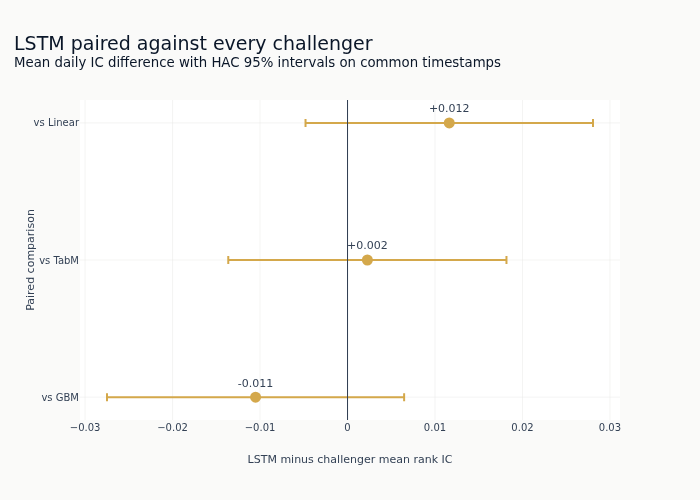

In [22]:
fig = go.Figure(
    go.Scatter(
        x=paired_deltas["delta"],
        y=[f"vs {FAMILY_LABELS[value]}" for value in paired_deltas["challenger"]],
        mode="markers+text",
        text=[f"{value:+.3f}" for value in paired_deltas["delta"]],
        textposition="top center",
        marker={"size": 11, "color": COLORS["amber"]},
        error_x={
            "type": "data",
            "symmetric": False,
            "array": (paired_deltas["ci_hi"] - paired_deltas["delta"]).to_list(),
            "arrayminus": (paired_deltas["delta"] - paired_deltas["ci_lo"]).to_list(),
        },
    )
)
fig.add_vline(x=0, line_color=COLORS["neutral"], line_width=1)
fig.update_layout(
    title={
        "text": f"{FAMILY_LABELS['deep_learning']} paired against every challenger"
        "<br><sup>Mean daily IC difference with HAC 95% intervals on common timestamps</sup>",
        "x": 0.02,
        "xanchor": "left",
    },
    xaxis_title=f"{FAMILY_LABELS['deep_learning']} minus challenger mean rank IC",
    yaxis_title="Paired comparison",
    showlegend=False,
)
fig.show()

## Ranking quality must also be monotone

IC summarizes ordering, but a tradable score should separate realized returns across score
quintiles. Each bucket is formed within a timestamp on the same aligned panel.

In [23]:
def _bucket_profile(frame: pl.DataFrame) -> pl.DataFrame:
    """Return mean realized return by within-timestamp score quintile."""
    ranked = frame.with_columns(
        (
            ((pl.col("y_score").rank("ordinal").over("timestamp") - 1) * N_BUCKETS)
            .truediv(pl.len().over("timestamp"))
            .floor()
            .cast(pl.Int8)
            + 1
        ).alias("bucket")
    )
    return (
        ranked.group_by("bucket")
        .agg(pl.col("y_true").mean().cast(pl.Float64).alias("mean_return"))
        .sort("bucket")
    )

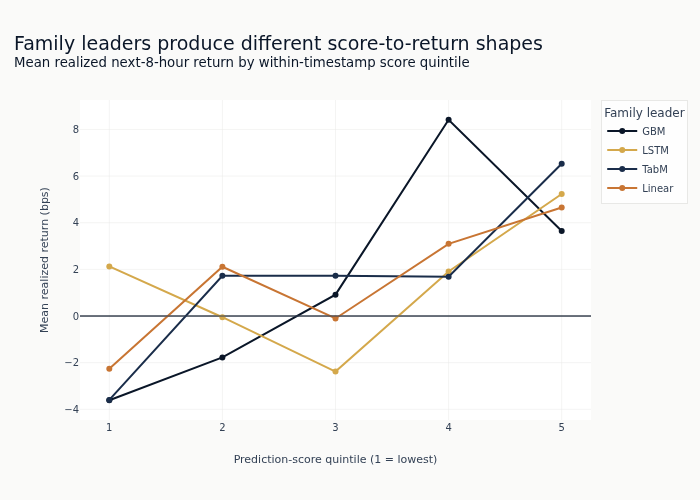

In [24]:
bucket_rows = []
for frame in aligned_frames:
    family = frame["family"][0]
    bucket_rows.append(_bucket_profile(frame).with_columns(pl.lit(family).alias("family")))
bucket_profiles = pl.concat(bucket_rows).sort(["family", "bucket"])

fig = go.Figure()
for family in comparison["family"]:
    profile = bucket_profiles.filter(pl.col("family") == family)
    fig.add_trace(
        go.Scatter(
            x=profile["bucket"],
            y=profile["mean_return"] * 10_000,
            mode="lines+markers",
            name=FAMILY_LABELS[family],
        )
    )
fig.add_hline(y=0, line_color=COLORS["neutral"], line_width=1)
fig.update_layout(
    title={
        "text": "Family leaders produce different score-to-return shapes"
        "<br><sup>Mean realized next-8-hour return by within-timestamp score quintile</sup>",
        "x": 0.02,
        "xanchor": "left",
    },
    xaxis_title="Prediction-score quintile (1 = lowest)",
    yaxis_title="Mean realized return (bps)",
    legend_title="Family leader",
)
fig.show()

## Low agreement leaves room for diversification, not automatic averaging

Scores are ranked within timestamp before correlation. Low correlation means the models order the
cross-section differently; it does not rescue a family whose IC interval includes zero.

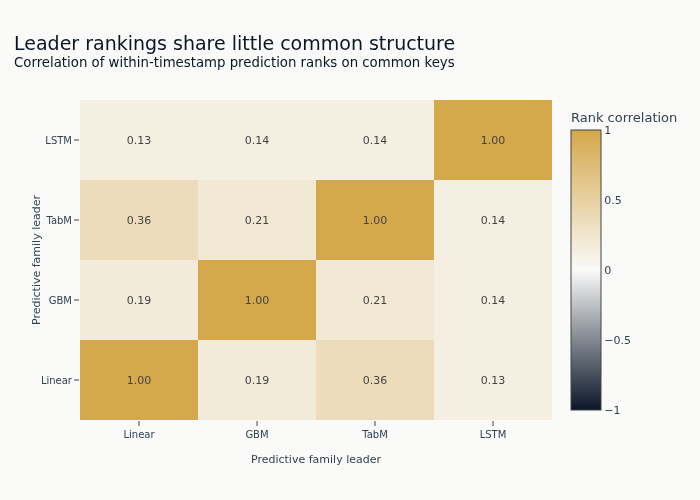

In [25]:
wide_scores = common_keys
score_columns = []
for frame in aligned_frames:
    family = frame["family"][0]
    column = f"score_{family}"
    score_columns.append(column)
    ranked = frame.select(
        "timestamp",
        "symbol",
        pl.col("y_score").rank("average").over("timestamp").alias(column),
    )
    wide_scores = wide_scores.join(ranked, on=["timestamp", "symbol"], how="inner")
corr = np.corrcoef(wide_scores.select(score_columns).to_numpy(), rowvar=False)
labels = [FAMILY_LABELS[column.removeprefix("score_")] for column in score_columns]

fig = go.Figure(
    go.Heatmap(
        z=corr,
        x=labels,
        y=labels,
        zmin=-1,
        zmax=1,
        colorscale=[[0, COLORS["blue"]], [0.5, COLORS["bg_light"]], [1, COLORS["amber"]]],
        text=np.round(corr, 2),
        texttemplate="%{text:.2f}",
        colorbar={"title": "Rank correlation"},
    )
)
fig.update_layout(
    title={
        "text": "Leader rankings share little common structure"
        "<br><sup>Correlation of within-timestamp prediction ranks on common keys</sup>",
        "x": 0.02,
        "xanchor": "left",
    },
    xaxis_title="Predictive family leader",
    yaxis_title="Predictive family leader",
)
fig.show()

## Causal evidence is not a fifth predictive family

Causal DML estimates a treatment effect rather than a cross-sectional forecast. Its current
signed result is reported separately and excluded from every predictive ranking and ensemble
diagnostic above.

In [26]:
uri = f"file:{REGISTRY_PATH}?mode=ro"
with sqlite3.connect(uri, uri=True) as connection:
    causal = pl.read_database(
        """
        SELECT causal_hash, dml_effect, dml_se_hac, p_value_hac, refutation_p
        FROM causal_runs
        WHERE label = ? AND notebook = '11_causal_dml'
        ORDER BY created_at DESC
        """,
        connection,
        execute_options={"parameters": (PRIMARY_LABEL,)},
    )
if causal.height:
    row = causal.row(0, named=True)
    print(
        f"Current causal row {row['causal_hash']}: effect={row['dml_effect']:+.6f}, "
        f"HAC p={row['p_value_hac']:.3f}"
    )

Current causal row b8478b89defb: effect=-0.000874, HAC p=0.342


## Pre-backtest judgment

GBM has the strongest common-panel point estimate at +0.0285. GBM, LSTM, and TabM each have a HAC
interval above zero, while Linear's interval includes zero. None of LSTM's paired differences
against the other families excludes zero, including LSTM minus GBM at -0.0105 with interval
[-0.0275, +0.0065]. The corrected lineage therefore supports GBM as the development leader but
not a statistically decisive family winner. This evidence does not license holdout inspection or
an unvalidated ensemble.

## Key takeaways

1. Physical checkpoint separation prevents epoch mixing and duplicate decision keys.
2. All four current family leaders share 35,228 validation rows and 2,183 decision timestamps.
3. GBM leads at +0.0285; LSTM follows at +0.0180, TabM at +0.0157, and Linear at +0.0063.
4. GBM, LSTM, and TabM intervals clear zero, but none of the three LSTM-versus-challenger paired
   intervals does. Point-estimate ranking is stronger than the evidence for pairwise superiority.
5. Low prediction correlation supports challenger testing, not an unvalidated equal-weight blend.
6. The signed causal result remains a separate estimand and does not enter predictive selection.

**Next**: [`13_backtest`](13_backtest.ipynb) tests forecast carriers after costs and turnover.